In [ ]:
import pandas as pd
import numpy as np

In [ ]:
import pandas as pd
file_path = '/content/medical_appointments_raw.csv.xlsx'
df = pd.read_excel(file_path)

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 110527
Columns: 14


In [ ]:
df.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       110527 non-null  float64
 1   AppointmentID   110527 non-null  int64  
 2   Gender          110527 non-null  object 
 3   ScheduledDay    110527 non-null  object 
 4   AppointmentDay  110527 non-null  object 
 5   Age             110527 non-null  int64  
 6   Neighbourhood   110527 non-null  object 
 7   Scholarship     110527 non-null  int64  
 8   Hipertension    110527 non-null  int64  
 9   Diabetes        110527 non-null  int64  
 10  Alcoholism      110527 non-null  int64  
 11  Handcap         110527 non-null  int64  
 12  SMS_received    110527 non-null  int64  
 13  No-show         110527 non-null  object 
dtypes: float64(1), int64(8), object(5)
memory usage: 11.8+ MB


In [ ]:
print(df.columns.tolist())

['PatientId', 'AppointmentID', 'Gender', 'ScheduledDay', 'AppointmentDay', 'Age', 'Neighbourhood', 'Scholarship', 'Hipertension', 'Diabetes', 'Alcoholism', 'Handcap', 'SMS_received', 'No-show']


In [ ]:
df.isnull().sum()

,0
PatientId,0
AppointmentID,0
Gender,0
ScheduledDay,0
AppointmentDay,0
Age,0
Neighbourhood,0
Scholarship,0
Hipertension,0
Diabetes,0


In [ ]:
df.describe()

,PatientId,AppointmentID,Age,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received
count,1.105270e+05,1.105270e+05,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000
mean,1.474963e+14,5.675305e+06,37.088874,0.098266,0.197246,0.071865,0.030400,0.022248,0.321026
std,2.560949e+14,7.129575e+04,23.110205,0.297675,0.397921,0.258265,0.171686,0.161543,0.466873
min,3.921784e+04,5.030230e+06,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.172614e+12,5.640286e+06,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.173184e+13,5.680573e+06,37.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,9.439172e+13,5.725524e+06,55.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,9.999816e+14,5.790484e+06,115.000000,1.000000,1.000000,1.000000,1.000000,4.000000,1.000000


In [ ]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [ ]:
df_clean = df.copy()
print("Rows:", df_clean.shape[0])
print("Columns:", df_clean.shape[1])

Rows: 110527
Columns: 14


In [ ]:
for columns in df_clean.columns:
  print(columns)

PatientId
AppointmentID
Gender
ScheduledDay
AppointmentDay
Age
Neighbourhood
Scholarship
Hipertension
Diabetes
Alcoholism
Handcap
SMS_received
No-show


In [ ]:
df_clean.columns=df_clean.columns.str.lower()
df_clean.columns=df_clean.columns.str.strip()

df_clean.columns = (
    df_clean.columns
    .str.replace(' ', '_')
    .str.replace('(', '')
    .str.replace(')', '')
    .str.replace('-', '_')
)
print(df_clean.columns.tolist())

['patientid', 'appointmentid', 'gender', 'scheduledday', 'appointmentday', 'age', 'neighbourhood', 'scholarship', 'hipertension', 'diabetes', 'alcoholism', 'handcap', 'sms_received', 'no_show']


In [ ]:
df_clean = df_clean.rename(columns={
    'patientid': 'patient_id',
    'appointmentid': 'appointment_id',
    'scheduledday': 'scheduled_day',
    'appointmentday': 'appointment_day',
    'hipertension': 'hypertension',
    'handcap': 'handicap',
    'sms_received': 'sms_received',
    'no_show': 'no_show'
})

# Display the cleaned column names
print(df_clean.columns.tolist())

['patient_id', 'appointment_id', 'gender', 'scheduled_day', 'appointment_day', 'age', 'neighbourhood', 'scholarship', 'hypertension', 'diabetes', 'alcoholism', 'handicap', 'sms_received', 'no_show']


In [ ]:
# Count missing values in every column
missing_values = df_clean.isnull().sum()

# Display only columns that contain missing values
print(missing_values[missing_values > 0])

Series([], dtype: int64)


In [ ]:
print("gender")
print(df_clean['gender'].unique())

gender
['F' 'M']


In [ ]:

# Display the unique values in the No-show column
print("\nNo-show:")
print(df_clean['no_show'].unique())

# Display the unique values in Scholarship
print("\nScholarship:")
print(df_clean['scholarship'].unique())

# Display the unique values in SMS received
print("\nSMS received:")
print(df_clean['sms_received'].unique())


No-show:
['No' 'Yes']

Scholarship:
[0 1]

SMS received:
[0 1]


In [ ]:
print(df_clean["age"].describe())

count    110527.000000
mean         37.088874
std          23.110205
min          -1.000000
25%          18.000000
50%          37.000000
75%          55.000000
max         115.000000
Name: age, dtype: float64


In [ ]:
# Find unusually low ages
print("Patients with age below 0:")
print((df_clean['age'] < 0).sum())

Patients with age below 0:
1


print("minimum_age:",df_clean[age].min())


In [ ]:
print("minimum_age:",df_clean["age"].min())
print("maximum_age:",df_clean["age"].max())

minimum_age: -1
maximum_age: 115


In [ ]:
print(df_clean[['scheduled_day','appointment_day']].dtypes)

scheduled_day      object
appointment_day    object
dtype: object


In [ ]:
# Convert ScheduledDay from text to datetime
df_clean['scheduled_day'] = pd.to_datetime(
    df_clean['scheduled_day']
)

# Convert AppointmentDay from text to datetime
df_clean['appointment_day'] = pd.to_datetime(
    df_clean['appointment_day']
)

# Check the data types again
print(df_clean[['scheduled_day', 'appointment_day']].dtypes)


scheduled_day      datetime64[ns, UTC]
appointment_day    datetime64[ns, UTC]
dtype: object


Waiting time in datws


In [ ]:
df_clean["waiting_time"]= (df_clean["appointment_day"]-df_clean["scheduled_day"]).dt.days
print(df_clean["waiting_time"])

0         -1
1         -1
2         -1
3         -1
4         -1
          ..
110522    34
110523    34
110524    40
110525    40
110526    40
Name: waiting_time, Length: 110527, dtype: int64


In [ ]:
print(df_clean["waiting_time"].describe())

count    110527.000000
mean          9.183702
std          15.254996
min          -7.000000
25%          -1.000000
50%           3.000000
75%          14.000000
max         178.000000
Name: waiting_time, dtype: float64


waiting time is negative,which means appointment date is before scheduled date?


In [ ]:
negative_waiting = (df_clean['waiting_time'] < 0).sum()

print("Negative waiting periods:", negative_waiting)

Negative waiting periods: 38568


In [ ]:
print("shape:",df_clean.shape)

print("Duplicates:",df_clean.duplicated().sum())

print("Negative waiting periods:", (df_clean['waiting_time'] < 0).sum())
print("Invalid ages:",
      (df_clean['age'] < 0).sum())

print(df_clean[['scheduled_day',
                'appointment_day',
                'waiting_time']].head())

shape: (110527, 15)
Duplicates: 0
Negative waiting periods: 38568
Invalid ages: 1
              scheduled_day           appointment_day  waiting_time
0 2016-04-29 18:38:08+00:00 2016-04-29 00:00:00+00:00            -1
1 2016-04-29 16:08:27+00:00 2016-04-29 00:00:00+00:00            -1
2 2016-04-29 16:19:04+00:00 2016-04-29 00:00:00+00:00            -1
3 2016-04-29 17:29:31+00:00 2016-04-29 00:00:00+00:00            -1
4 2016-04-29 16:07:23+00:00 2016-04-29 00:00:00+00:00            -1


age cant be negative


In [ ]:
df_clean = df_clean.rename(columns={'waiting_time': 'waiting_days'})

In [ ]:
df_clean.loc[df_clean['age'] < 0, 'age'] = np.nan

In [ ]:
print("minimum age:",df_clean["age"].min())

minimum age: 0.0


age categories


In [ ]:


# Create age categories using the patient's age
df_clean['age_group'] = pd.cut(
    df_clean['age'],

    # Define the boundaries of each age group
    bins=[0, 12, 18, 30, 45, 60, 75, 120],

    # Give each age range a meaningful name
    labels=[
        'Child',
        'Teenager',
        'Young Adult',
        'Adult',
        'Middle Age',
        'Senior',
        'Elderly'
    ],

    # Include the lower boundary in each interval
    include_lowest=True
)

# Check how many patients are in each age group
print(df_clean['age_group'].value_counts().sort_index())

age_group
Child          21036
Teenager        7830
Young Adult    16765
Adult          21954
Middle Age     23179
Senior         14370
Elderly         5392
Name: count, dtype: int64


no-show flag


In [ ]:
df_clean.head()

,patient_id,appointment_id,gender,scheduled_day,appointment_day,age,neighbourhood,scholarship,hypertension,diabetes,alcoholism,handicap,sms_received,no_show,waiting_days,age_group
0,2.987250e+13,5642903,F,2016-04-29 18:38:08+00:00,2016-04-29 00:00:00+00:00,62.0,JARDIM DA PENHA,0,1,0,0,0,0,No,-1,Senior
1,5.589978e+14,5642503,M,2016-04-29 16:08:27+00:00,2016-04-29 00:00:00+00:00,56.0,JARDIM DA PENHA,0,0,0,0,0,0,No,-1,Middle Age
2,4.262962e+12,5642549,F,2016-04-29 16:19:04+00:00,2016-04-29 00:00:00+00:00,62.0,MATA DA PRAIA,0,0,0,0,0,0,No,-1,Senior
3,8.679512e+11,5642828,F,2016-04-29 17:29:31+00:00,2016-04-29 00:00:00+00:00,8.0,PONTAL DE CAMBURI,0,0,0,0,0,0,No,-1,Child
4,8.841186e+12,5642494,F,2016-04-29 16:07:23+00:00,2016-04-29 00:00:00+00:00,56.0,JARDIM DA PENHA,0,1,1,0,0,0,No,-1,Middle Age


In [ ]:
df_clean['no_show'] = df['No-show'].copy()

# Check that the values are restored correctly
print(df_clean['no_show'].value_counts())

no_show
No     88208
Yes    22319
Name: count, dtype: int64


In [ ]:
df_clean['no_show'] = np.where(df_clean['no_show'] == 'Yes', 1, 0)
print(df_clean['no_show'].value_counts())

no_show
0    88208
1    22319
Name: count, dtype: int64


In [ ]:
# Create a clear attendance status
df_clean['attendance_status'] = np.where(
    df_clean['no_show'] == 1,
    'No-Show',
    'Attended'
)

# Check the distribution
print(df_clean['attendance_status'].value_counts())

attendance_status
Attended    88208
No-Show     22319
Name: count, dtype: int64


Which days of the week have the highest no-show rates


In [ ]:
df_clean["appointment_weekday"] = df_clean["appointment_day"].dt.day_name()
print(df_clean['appointment_weekday'].value_counts())

appointment_weekday
Wednesday    25867
Tuesday      25640
Monday       22715
Friday       19019
Thursday     17247
Saturday        39
Name: count, dtype: int64


In [ ]:
df_clean['weekday_number'] = (
    df_clean['appointment_day'].dt.weekday
)

# Check the result
print(
    df_clean[
        ['appointment_weekday', 'weekday_number']
    ].drop_duplicates().sort_values('weekday_number')
)

      appointment_weekday  weekday_number
3295               Monday               0
3235              Tuesday               1
3310            Wednesday               2
3328             Thursday               3
0                  Friday               4
72295            Saturday               5


monthly trends


In [ ]:
df_clean["appointment_month"] = df_clean["appointment_day"].dt.month
print(df_clean["appointment_month"].value_counts())

appointment_month
5    80841
6    26451
4     3235
Name: count, dtype: int64


In [ ]:
# Create a year-month column
# Example: 2016-04, 2016-05, etc.
df_clean['appointment_year_month'] = (
    df_clean['appointment_day']
    .dt.to_period('M')
    .astype(str)
)

# Display the first few values
print(df_clean['appointment_year_month'].head())

0    2016-04
1    2016-04
2    2016-04
3    2016-04
4    2016-04
Name: appointment_year_month, dtype: object


/tmp/ipykernel_857/516159698.py:5: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  .dt.to_period('M')


In [ ]:
df_clean['waiting_category'] = pd.cut(
    df_clean['waiting_days'],

    # Define waiting-time ranges
    bins=[-1, 0, 3, 7, 14, 30, 60, 1000],

    # Give each range a meaningful name
    labels=[
        'Same Day',
        '1-3 Days',
        '4-7 Days',
        '8-14 Days',
        '15-30 Days',
        '31-60 Days',
        '60+ Days'
    ]
)

# Check the distribution
print(df_clean['waiting_category'].value_counts())

waiting_category
15-30 Days    16540
1-3 Days      14752
4-7 Days      14552
8-14 Days     11196
31-60 Days     7746
Same Day       5213
60+ Days       1960
Name: count, dtype: int64


In [ ]:
# Create an elderly patient flag
# 1 = age 60 or above
# 0 = below 60
df_clean['elderly_flag'] = np.where(
    df_clean['age'] >= 60,
    1,
    0
)

# Check the results
print(df_clean['elderly_flag'].value_counts())

elderly_flag
0    89354
1    21173
Name: count, dtype: int64


In [ ]:
df_clean["health_condition"] = (df_clean["hypertension"]+df_clean["diabetes"]+df_clean["alcoholism"])
print(df_clean["health_condition"].value_counts().sort_index())

health_condition
0    85312
1    17582
2     7377
3      256
Name: count, dtype: int64


In [ ]:
df_clean.head()

,patient_id,appointment_id,gender,scheduled_day,appointment_day,age,neighbourhood,scholarship,hypertension,diabetes,...,waiting_days,age_group,attendance_status,appointment_weekday,weekday_number,appointment_month,appointment_year_month,waiting_category,elderly_flag,health_condition
0,2.987250e+13,5642903,F,2016-04-29 18:38:08+00:00,2016-04-29 00:00:00+00:00,62.0,JARDIM DA PENHA,0,1,0,...,-1,Senior,Attended,Friday,4,4,2016-04,NaN,1,1
1,5.589978e+14,5642503,M,2016-04-29 16:08:27+00:00,2016-04-29 00:00:00+00:00,56.0,JARDIM DA PENHA,0,0,0,...,-1,Middle Age,Attended,Friday,4,4,2016-04,NaN,0,0
2,4.262962e+12,5642549,F,2016-04-29 16:19:04+00:00,2016-04-29 00:00:00+00:00,62.0,MATA DA PRAIA,0,0,0,...,-1,Senior,Attended,Friday,4,4,2016-04,NaN,1,0
3,8.679512e+11,5642828,F,2016-04-29 17:29:31+00:00,2016-04-29 00:00:00+00:00,8.0,PONTAL DE CAMBURI,0,0,0,...,-1,Child,Attended,Friday,4,4,2016-04,NaN,0,0
4,8.841186e+12,5642494,F,2016-04-29 16:07:23+00:00,2016-04-29 00:00:00+00:00,56.0,JARDIM DA PENHA,0,1,1,...,-1,Middle Age,Attended,Friday,4,4,2016-04,NaN,0,2


In [ ]:
df_clean.to_csv(
    '/content/medical_appointments_cleaned.csv',
    index=False
)
print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


In [ ]:
# Calculate total appointments
df_clean["total_appointments"] = len(df_clean)



In [ ]:
import pandas as pd

# Calculate total appointments
total_appointments = len(df_clean)

# Calculate unique patients
total_patients = df_clean['patient_id'].nunique()

# Calculate attended appointments
total_attended = df_clean[df_clean['no_show'] == 0].shape[0]

# Calculate no-show appointments
total_no_shows = df_clean[df_clean['no_show'] == 1].shape[0]

# Calculate attendance percentage
attendance_rate = (total_attended / total_appointments) * 100

# Calculate no-show percentage
no_show_rate = (total_no_shows / total_appointments) * 100

kpi_summary = pd.DataFrame({

    # Names of the KPIs
    'Metric': [
        'Total Appointments',
        'Unique Patients',
        'Attended Appointments',
        'No-Show Appointments',
        'Attendance Rate (%)',
        'No-Show Rate (%)'
    ],

    # Corresponding KPI values
    'Value': [
        total_appointments,
        total_patients,
        total_attended,
        total_no_shows,
        round(attendance_rate, 2),
        round(no_show_rate, 2)
    ]
})

# Display the KPI table
kpi_summary

,Metric,Value
0,Total Appointments,110527.00
1,Unique Patients,62299.00
2,Attended Appointments,88208.00
3,No-Show Appointments,22319.00
4,Attendance Rate (%),79.81
5,No-Show Rate (%),20.19


Attendance vs No-Show

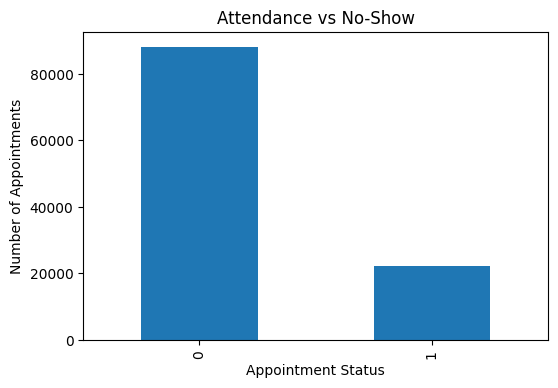

In [ ]:
import matplotlib.pyplot as plt

# Count attendance status
attendance_counts = df_clean['no_show'].value_counts()

# Create chart
plt.figure(figsize=(6,4))

attendance_counts.plot(
    kind='bar'
)

plt.title("Attendance vs No-Show")
plt.xlabel("Appointment Status")
plt.ylabel("Number of Appointments")

plt.show()

No-show rate by age group

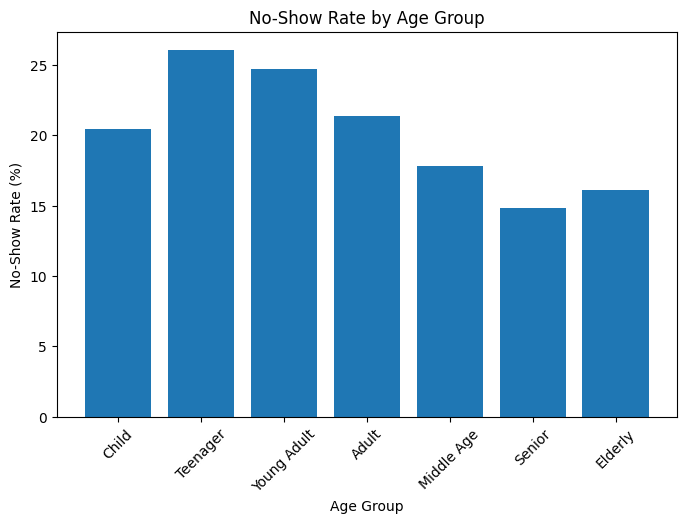

In [ ]:
# Create age group analysis
age_analysis = (
    df_clean
    .groupby('age_group', observed=True)['no_show']
    .mean()
    .reset_index()
)

# Convert to percentage
age_analysis['no_show'] *= 100

# Plot
plt.figure(figsize=(8,5))

plt.bar(
    age_analysis['age_group'],
    age_analysis['no_show']
)

plt.title("No-Show Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("No-Show Rate (%)")

plt.xticks(rotation=45)

plt.show()

No-show rate by weekday

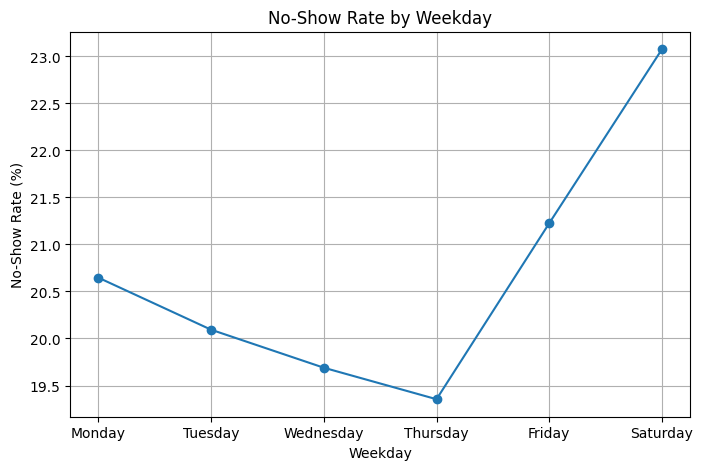

In [ ]:
weekday_analysis = (
    df_clean
    .groupby(
        ['weekday_number',
         'appointment_weekday']
    )['no_show']
    .mean()
    .reset_index()
)

weekday_analysis['no_show'] *= 100

weekday_analysis = (
    weekday_analysis
    .sort_values('weekday_number')
)

plt.figure(figsize=(8,5))

plt.plot(
    weekday_analysis['appointment_weekday'],
    weekday_analysis['no_show'],
    marker='o'
)

plt.title("No-Show Rate by Weekday")
plt.xlabel("Weekday")
plt.ylabel("No-Show Rate (%)")

plt.grid(True)

plt.show()

SMS reminder analysis

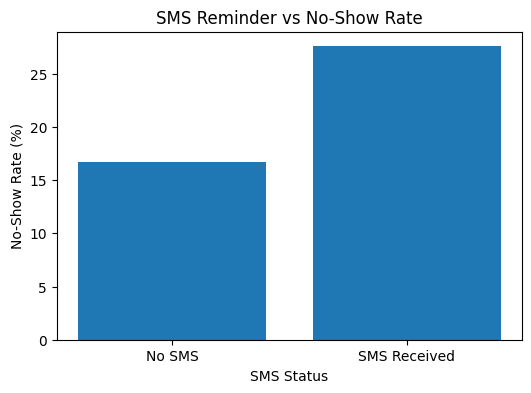

In [ ]:

sms_analysis = (
    df_clean
    .groupby('sms_received')['no_show']
    .mean()
    .reset_index()
)

sms_analysis['no_show'] *= 100

# Replace values with readable labels
sms_analysis['sms_received'] = (
    sms_analysis['sms_received']
    .map({
        0:'No SMS',
        1:'SMS Received'
    })
)

plt.figure(figsize=(6,4))

plt.bar(
    sms_analysis['sms_received'],
    sms_analysis['no_show']
)

plt.title("SMS Reminder vs No-Show Rate")
plt.xlabel("SMS Status")
plt.ylabel("No-Show Rate (%)")

plt.show()

Waiting period analysis

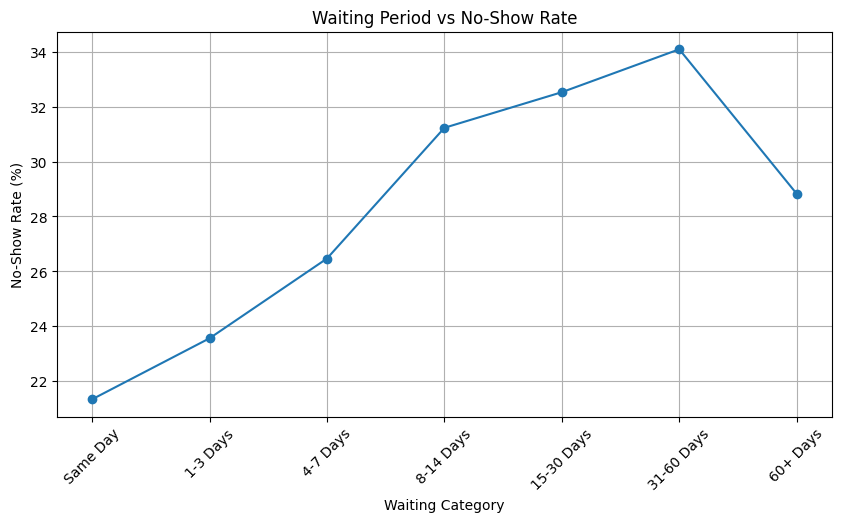

In [ ]:
waiting_analysis = (
    df_clean
    .groupby(
        'waiting_category',
        observed=True
    )['no_show']
    .mean()
    .reset_index()
)

waiting_analysis['no_show'] *= 100

plt.figure(figsize=(10,5))

plt.plot(
    waiting_analysis['waiting_category'],
    waiting_analysis['no_show'],
    marker='o'
)

plt.title("Waiting Period vs No-Show Rate")
plt.xlabel("Waiting Category")
plt.ylabel("No-Show Rate (%)")

plt.xticks(rotation=45)

plt.grid(True)

plt.show()

Monthly appointment trend

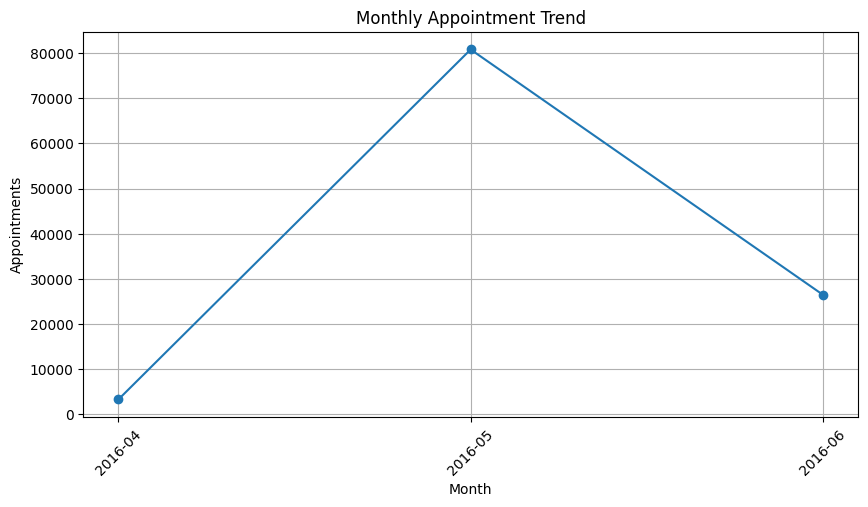

In [ ]:
monthly_analysis = (
    df_clean
    .groupby('appointment_year_month')
    .size()
    .reset_index(name='appointments')
)

plt.figure(figsize=(10,5))

plt.plot(
    monthly_analysis['appointment_year_month'],
    monthly_analysis['appointments'],
    marker='o'
)

plt.title("Monthly Appointment Trend")
plt.xlabel("Month")
plt.ylabel("Appointments")

plt.xticks(rotation=45)

plt.grid(True)

plt.show()

Top neighbourhoods by no-show rate

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 141 (\x8d) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129 (\x81) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


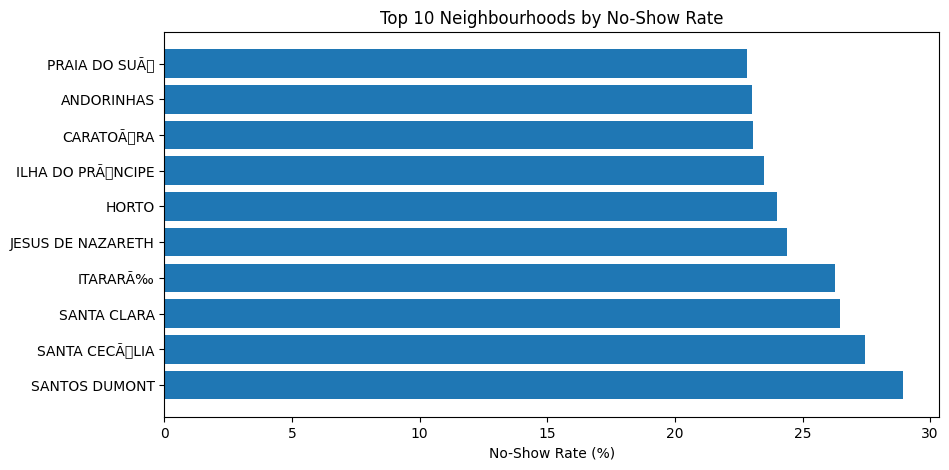

In [ ]:
neighbourhood_analysis = (
    df_clean
    .groupby('neighbourhood')['no_show']
    .agg(
        appointments='count',
        no_show_rate='mean'
    )
    .reset_index()
)

# Minimum 100 appointments
neighbourhood_analysis = (
    neighbourhood_analysis[
        neighbourhood_analysis['appointments'] >= 100
    ]
)

neighbourhood_analysis['no_show_rate'] *= 100

top10 = (
    neighbourhood_analysis
    .sort_values(
        'no_show_rate',
        ascending=False
    )
    .head(10)
)

plt.figure(figsize=(10,5))

plt.barh(
    top10['neighbourhood'],
    top10['no_show_rate']
)

plt.title("Top 10 Neighbourhoods by No-Show Rate")
plt.xlabel("No-Show Rate (%)")

plt.show()

In [ ]:
df_clean.columns.tolist()

['patient_id',
 'appointment_id',
 'gender',
 'scheduled_day',
 'appointment_day',
 'age',
 'neighbourhood',
 'scholarship',
 'hypertension',
 'diabetes',
 'alcoholism',
 'handicap',
 'sms_received',
 'no_show',
 'waiting_days',
 'age_group',
 'attendance_status',
 'appointment_weekday',
 'weekday_number',
 'appointment_month',
 'appointment_year_month',
 'waiting_category',
 'elderly_flag',
 'health_condition',
 'total_appointments']

In [ ]:
df_clean.to_csv("healthcare_cleaned.csv", index=False)

In [ ]:
df_clean.to_csv(
    "healthcare_cleaned_utf8.csv",
    index=False,
    encoding="utf-8"
)

from google.colab import files
files.download("healthcare_cleaned_utf8.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Remove special characters from text columns

for col in df_clean.select_dtypes(include='object').columns:
    df_clean[col] = (
        df_clean[col]
        .astype(str)
        .str.encode('ascii', errors='ignore')
        .str.decode('ascii')
    )

df_clean.to_csv(
    "healthcare_cleaned_ascii.csv",
    index=False,
    encoding="utf-8"
)

from google.colab import files
files.download("healthcare_cleaned_ascii.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
df_clean.shape

(110527, 25)

In [ ]:
df_clean[['scheduled_day','appointment_day']].head()

,scheduled_day,appointment_day
0,2016-04-29 18:38:08+00:00,2016-04-29 00:00:00+00:00
1,2016-04-29 16:08:27+00:00,2016-04-29 00:00:00+00:00
2,2016-04-29 16:19:04+00:00,2016-04-29 00:00:00+00:00
3,2016-04-29 17:29:31+00:00,2016-04-29 00:00:00+00:00
4,2016-04-29 16:07:23+00:00,2016-04-29 00:00:00+00:00


In [ ]:
df_clean['scheduled_day'] = pd.to_datetime(df_clean['scheduled_day']).dt.tz_localize(None)
df_clean['appointment_day'] = pd.to_datetime(df_clean['appointment_day']).dt.tz_localize(None)

In [ ]:
df_clean.to_csv("healthcare_mysql.csv", index=False)

from google.colab import files
files.download("healthcare_mysql.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>